<a href="https://colab.research.google.com/github/amruthachintada/Credit_Scoring_Model.ipynb/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving german_credit_data.csv to german_credit_data (1).csv

First 5 Rows
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  

Dataset Shape: (1000, 10)

Missing Values
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving

/tmp/ipykernel_1313/1987192806.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1313/1987192806.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 


Accuracy : 100.0 %

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00       175

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



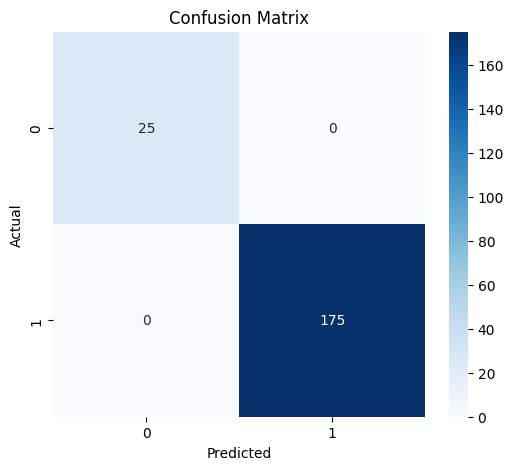

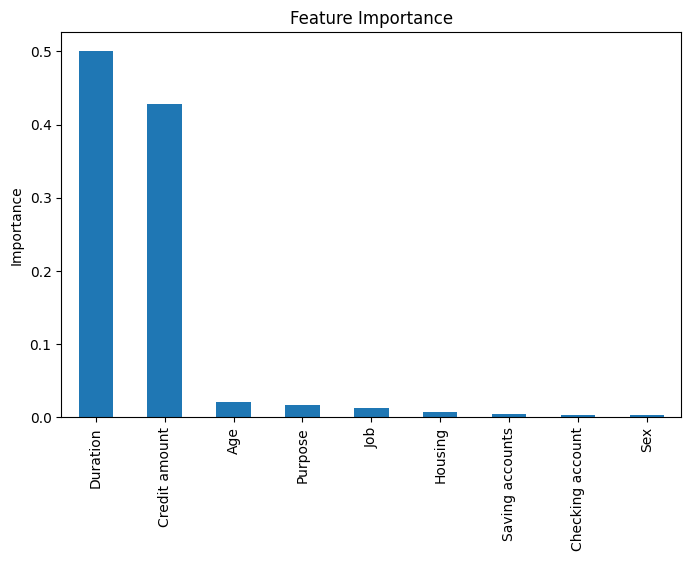


Prediction for First Customer:
Good Credit Risk

Project Completed Successfully!


In [4]:
# ==========================================================
# CodeAlpha Internship
# Credit Scoring Model (Works with german_credit_data.csv)
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================================
# Upload Dataset
# ==========================================================

uploaded = files.upload()

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("german_credit_data.csv")

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# Remove Unnecessary Column
# ==========================================================

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# ==========================================================
# Fill Missing Values
# ==========================================================

for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

# ==========================================================
# Encode Categorical Columns
# ==========================================================

encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

# ==========================================================
# Create Target Column
# (Demo Purpose)
# ==========================================================

df["Risk"] = np.where(
    (df["Credit amount"] > 4000) &
    (df["Duration"] > 24),
    0,
    1
)

# 1 = Good Credit
# 0 = Bad Credit

print("\nRisk Distribution")
print(df["Risk"].value_counts())

# ==========================================================
# Features & Target
# ==========================================================

X = df.drop("Risk", axis=1)
y = df["Risk"]

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# Train Model
# ==========================================================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================================
# Prediction
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# Accuracy
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", round(accuracy*100,2), "%")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report")

print(classification_report(y_test, y_pred))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.show()

# ==========================================================
# Predict First Customer
# ==========================================================

sample = X.iloc[[0]]

prediction = model.predict(sample)

print("\nPrediction for First Customer:")

if prediction[0] == 1:
    print("Good Credit Risk")
else:
    print("Bad Credit Risk")

print("\nProject Completed Successfully!")